In [14]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.20.0
GPU Available: []


In [15]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth configured successfully!")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("No GPU detected. Training will use CPU.")

BASE_PATH = os.path.join(os.path.expanduser('~'), 'Desktop', 'BrainTumorProject', 'archive')
TRAIN_DIR = os.path.join(BASE_PATH, 'Training')
TEST_DIR = os.path.join(BASE_PATH, 'Testing')

print(f"Training data: {TRAIN_DIR}")
print(f"Testing data: {TEST_DIR}")
print(f"Training folder exists: {os.path.exists(TRAIN_DIR)}")
print(f"Testing folder exists: {os.path.exists(TEST_DIR)}")

No GPU detected. Training will use CPU.
Training data: C:\Users\Akash\Desktop\BrainTumorProject\archive\Training
Testing data: C:\Users\Akash\Desktop\BrainTumorProject\archive\Testing
Training folder exists: True
Testing folder exists: True


In [16]:
if os.path.exists(TRAIN_DIR):
    classes = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
    classes.sort()
    print(f"Detected classes: {classes}")
    print(f"Number of classes: {len(classes)}")
    
    print("\n--- Training Data Distribution ---")
    for class_name in classes:
        class_path = os.path.join(TRAIN_DIR, class_name)
        img_count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"{class_name}: {img_count} images")
    
    print("\n--- Testing Data Distribution ---")
    for class_name in classes:
        class_path = os.path.join(TEST_DIR, class_name)
        if os.path.exists(class_path):
            img_count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            print(f"{class_name}: {img_count} images")

Detected classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4

--- Training Data Distribution ---
glioma: 1321 images
meningioma: 1339 images
notumor: 1595 images
pituitary: 1457 images

--- Testing Data Distribution ---
glioma: 300 images
meningioma: 306 images
notumor: 405 images
pituitary: 300 images


In [17]:
IMG_SIZE = (224, 224)
NUM_CLASSES = len(classes)
BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 0.0001

print("=== MobileNetV3 Training Configuration ===")
print(f"Image size: {IMG_SIZE}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")

=== MobileNetV3 Training Configuration ===
Image size: (224, 224)
Number of classes: 4
Batch size: 16
Epochs: 30
Learning rate: 0.0001


In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print("Data generators created!")
print(f"Training batches per epoch: {train_generator.samples // BATCH_SIZE}")
print(f"Validation batches: {val_generator.samples // BATCH_SIZE}")
print(f"Class indices: {train_generator.class_indices}")

Found 5712 images belonging to 4 classes.
Found 1312 images belonging to 4 classes.
Data generators created!
Training batches per epoch: 357
Validation batches: 82
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [19]:
def build_mobilenetv3_model(img_size, num_classes):
    base_model = MobileNetV3Large(
        weights='imagenet',
        include_top=False,
        input_shape=(*img_size, 3)
    )
    
    base_model.trainable = False
    
    x = base_model.output
    x = GlobalAveragePooling2D(name='avg_pool')(x)
    x = Dense(256, activation='relu', name='fc1')(x)
    x = Dropout(0.4, name='dropout1')(x)
    x = Dense(128, activation='relu', name='fc2')(x)
    x = Dropout(0.2, name='dropout2')(x)
    predictions = Dense(num_classes, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions, name='MobileNetV3_BrainTumor')
    
    return model

print("Building MobileNetV3 model...")
model = build_mobilenetv3_model(IMG_SIZE, NUM_CLASSES)

print("\n=== MOBILENETV3 ARCHITECTURE ===")
model.summary()

print(f"\nTotal parameters: {model.count_params():,}")
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {model.count_params() - trainable_params:,}")

Building MobileNetV3 model...

=== MOBILENETV3 ARCHITECTURE ===


Model: "MobileNetV3_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv (Conv2D)                 │ (None, 112, 112, 16)      │             432 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_bn (BatchNormalization)  │ (None, 112, 112, 16)      │              64 │ conv[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_20 (Activation)    │ (None, 112, 112, 16)      │               0 │ conv_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 16)      │             144 │ activation_20[0][0]        │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_bn    │ (None, 112, 112, 16)      │              64 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_19 (ReLU)               │ (None, 112, 112, 16)      │               0 │ expanded_conv_depthwise_b… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             256 │ re_lu_19[0][0]             │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_bn      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_add (Add)       │ (None, 112, 112, 16)      │               0 │ activation_20[0][0],       │
│                               │                           │                 │ expanded_conv_project_bn[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_1_expand        │ (None, 112, 112, 64)      │           1,024 │ expanded_conv_add[0][0]    │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_1_expand_bn     │ (None, 112, 112, 64)      │             256 │ expanded_conv_1_expand[0]… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_20 (ReLU)               │ (None, 112, 112, 64)      │               

 Total params: 3,275,780 (12.50 MB)

 Trainable params: 279,428 (1.07 MB)

 Non-trainable params: 2,996,352 (11.43 MB)


Total parameters: 3,275,780
Trainable parameters: 279,428
Non-trainable parameters: 2,996,352


In [20]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print("MobileNetV3 compiled successfully!")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Loss function: categorical_crossentropy")
print(f"Metrics: accuracy, precision, recall")

MobileNetV3 compiled successfully!
Optimizer: Adam (lr=0.0001)
Loss function: categorical_crossentropy
Metrics: accuracy, precision, recall


In [21]:
os.makedirs('models', exist_ok=True)

callbacks = [
    ModelCheckpoint(
        'models/best_mobilenetv3_brain_tumor.h5',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configured:")
print(" ModelCheckpoint: Saves best model")
print(" EarlyStopping: Prevents overfitting")
print(" ReduceLROnPlateau: Adjusts learning rate")

Callbacks configured:
 ModelCheckpoint: Saves best model
 EarlyStopping: Prevents overfitting
 ReduceLROnPlateau: Adjusts learning rate


In [11]:
print("="*60)
print("STARTING MOBILENETV3 TRAINING")
print("="*60)
print(f"Training on {train_generator.samples} images")
print(f"Validating on {val_generator.samples} images")
print("-"*60)

steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = val_generator.samples // BATCH_SIZE

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*60)
print("MOBILENETV3 TRAINING COMPLETED!")
print("="*60)

STARTING MOBILENETV3 TRAINING
Training on 5712 images
Validating on 1312 images
------------------------------------------------------------


C:\Users\Akash\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.3304 - loss: 1.3537 - precision: 0.6848 - recall: 0.0674  
Epoch 1: val_accuracy improved from None to 0.37805, saving model to models/best_mobilenetv3_brain_tumor.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 168s 457ms/step - accuracy: 0.3697 - loss: 1.2908 - precision: 0.8269 - recall: 0.0979 - val_accuracy: 0.3780 - val_loss: 1.2610 - val_precision: 0.7190 - val_recall: 0.1502 - learning_rate: 1.0000e-04
Epoch 2/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.4165 - loss: 1.2180 - precision: 0.8632 - recall: 0.1243  
Epoch 2: val_accuracy improved from 0.37805 to 0.52820, saving model to models/best_mobilenetv3_brain_tumor.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 111s 311ms/step - accuracy: 0.4370 - loss: 1.1954 - precision: 0.8877 - recall: 0.1315 - val_accuracy: 0.5282 - val_loss: 1.2228 - val_precision: 0.7390 - val_recall: 0.1532 - learning_rate: 1.0000e-04
Epoch 3/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.4827 - loss: 1.1403 - precision: 0.8909 - recall: 0.1524  
Epoch 3: val_accuracy did not improve from 0.52820
357/357 ━━━━━━━━━━━━━━━━━━━━ 109s 306ms/step - accuracy: 0.4977 - loss: 1.1295 - precision: 0.8705 - recall: 0.1530 - val_accuracy: 0.5145 - val_loss: 1.1398 - val_precision: 0.7240 - val_recall: 0.1860 - learning_rate: 1.0000e-04
Epoch 4/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.5333 - loss: 1.0995 - precision: 0.8269 - recall: 0.1683  
Epoch 4: val_accuracy improved from 0.52820 to 0.55640, saving model to models/best_mobilenetv3_brain_tumor.h5


...

357/357 ━━━━━━━━━━━━━━━━━━━━ 120s 337ms/step - accuracy: 0.6829 - loss: 0.7719 - precision: 0.7456 - recall: 0.5751 - val_accuracy: 0.6814 - val_loss: 0.8029 - val_precision: 0.7163 - val_recall: 0.6273 - learning_rate: 1.0000e-04
Epoch 20/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.6851 - loss: 0.7557 - precision: 0.7491 - recall: 0.5877  
Epoch 20: val_accuracy improved from 0.68140 to 0.68826, saving model to models/best_mobilenetv3_brain_tumor.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 121s 338ms/step - accuracy: 0.6926 - loss: 0.7526 - precision: 0.7579 - recall: 0.5942 - val_accuracy: 0.6883 - val_loss: 0.7764 - val_precision: 0.7201 - val_recall: 0.6334 - learning_rate: 1.0000e-04
Epoch 21/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.6771 - loss: 0.7879 - precision: 0.7419 - recall: 0.5794  
Epoch 21: val_accuracy did not improve from 0.68826
357/357 ━━━━━━━━━━━━━━━━━━━━ 121s 337ms/step - accuracy: 0.6866 - loss: 0.7641 - precision: 0.7522 - recall: 0.5898 - val_accuracy: 0.6768 - val_loss: 0.7829 - val_precision: 0.7153 - val_recall: 0.6204 - learning_rate: 1.0000e-04
Epoch 22/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.6927 - loss: 0.7581 - precision: 0.7506 - recall: 0.5834  
Epoch 22: val_accuracy did not improve from 0.68826
357/357 ━━━━━━━━━━━━━━━━━━━━ 121s 338ms/step - accuracy: 0.6903 - loss: 0.7569 - precision: 0.7527 - recall: 0.5888 - val_accuracy: 0.6806 - val_loss: 0.7838 - val_precision: 0.7

357/357 ━━━━━━━━━━━━━━━━━━━━ 121s 338ms/step - accuracy: 0.6938 - loss: 0.7500 - precision: 0.7554 - recall: 0.5986 - val_accuracy: 0.6997 - val_loss: 0.7606 - val_precision: 0.7416 - val_recall: 0.6387 - learning_rate: 1.0000e-04
Epoch 24/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.6833 - loss: 0.7505 - precision: 0.7585 - recall: 0.5833  
Epoch 24: val_accuracy did not improve from 0.69970
357/357 ━━━━━━━━━━━━━━━━━━━━ 123s 345ms/step - accuracy: 0.6975 - loss: 0.7334 - precision: 0.7589 - recall: 0.6024 - val_accuracy: 0.6974 - val_loss: 0.7542 - val_precision: 0.7349 - val_recall: 0.6509 - learning_rate: 1.0000e-04
Epoch 25/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.7130 - loss: 0.7294 - precision: 0.7687 - recall: 0.6218  
Epoch 25: val_accuracy did not improve from 0.69970
357/357 ━━━━━━━━━━━━━━━━━━━━ 122s 341ms/step - accuracy: 0.7062 - loss: 0.7398 - precision: 0.7625 - recall: 0.6092 - val_accuracy: 0.6890 - val_loss: 0.7723 - val_precision: 0.7

357/357 ━━━━━━━━━━━━━━━━━━━━ 122s 341ms/step - accuracy: 0.7012 - loss: 0.7375 - precision: 0.7618 - recall: 0.6092 - val_accuracy: 0.7058 - val_loss: 0.7389 - val_precision: 0.7440 - val_recall: 0.6578 - learning_rate: 1.0000e-04
Epoch 27/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.7032 - loss: 0.7277 - precision: 0.7623 - recall: 0.6141  
Epoch 27: val_accuracy did not improve from 0.70579
357/357 ━━━━━━━━━━━━━━━━━━━━ 122s 341ms/step - accuracy: 0.6973 - loss: 0.7325 - precision: 0.7596 - recall: 0.6068 - val_accuracy: 0.7012 - val_loss: 0.7410 - val_precision: 0.7413 - val_recall: 0.6463 - learning_rate: 1.0000e-04
Epoch 28/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.7022 - loss: 0.7376 - precision: 0.7621 - recall: 0.6099  
Epoch 28: val_accuracy did not improve from 0.70579
357/357 ━━━━━━━━━━━━━━━━━━━━ 125s 349ms/step - accuracy: 0.7066 - loss: 0.7292 - precision: 0.7633 - recall: 0.6189 - val_accuracy: 0.7027 - val_loss: 0.7497 - val_precision: 0.7

357/357 ━━━━━━━━━━━━━━━━━━━━ 154s 432ms/step - accuracy: 0.7099 - loss: 0.7200 - precision: 0.7648 - recall: 0.6252 - val_accuracy: 0.7119 - val_loss: 0.7184 - val_precision: 0.7483 - val_recall: 0.6639 - learning_rate: 1.0000e-04
Epoch 30/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.7067 - loss: 0.7172 - precision: 0.7646 - recall: 0.6233  
Epoch 30: val_accuracy did not improve from 0.71189
357/357 ━━━━━━━━━━━━━━━━━━━━ 157s 440ms/step - accuracy: 0.7041 - loss: 0.7224 - precision: 0.7643 - recall: 0.6199 - val_accuracy: 0.7058 - val_loss: 0.7194 - val_precision: 0.7427 - val_recall: 0.6578 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 29.

MOBILENETV3 TRAINING COMPLETED!


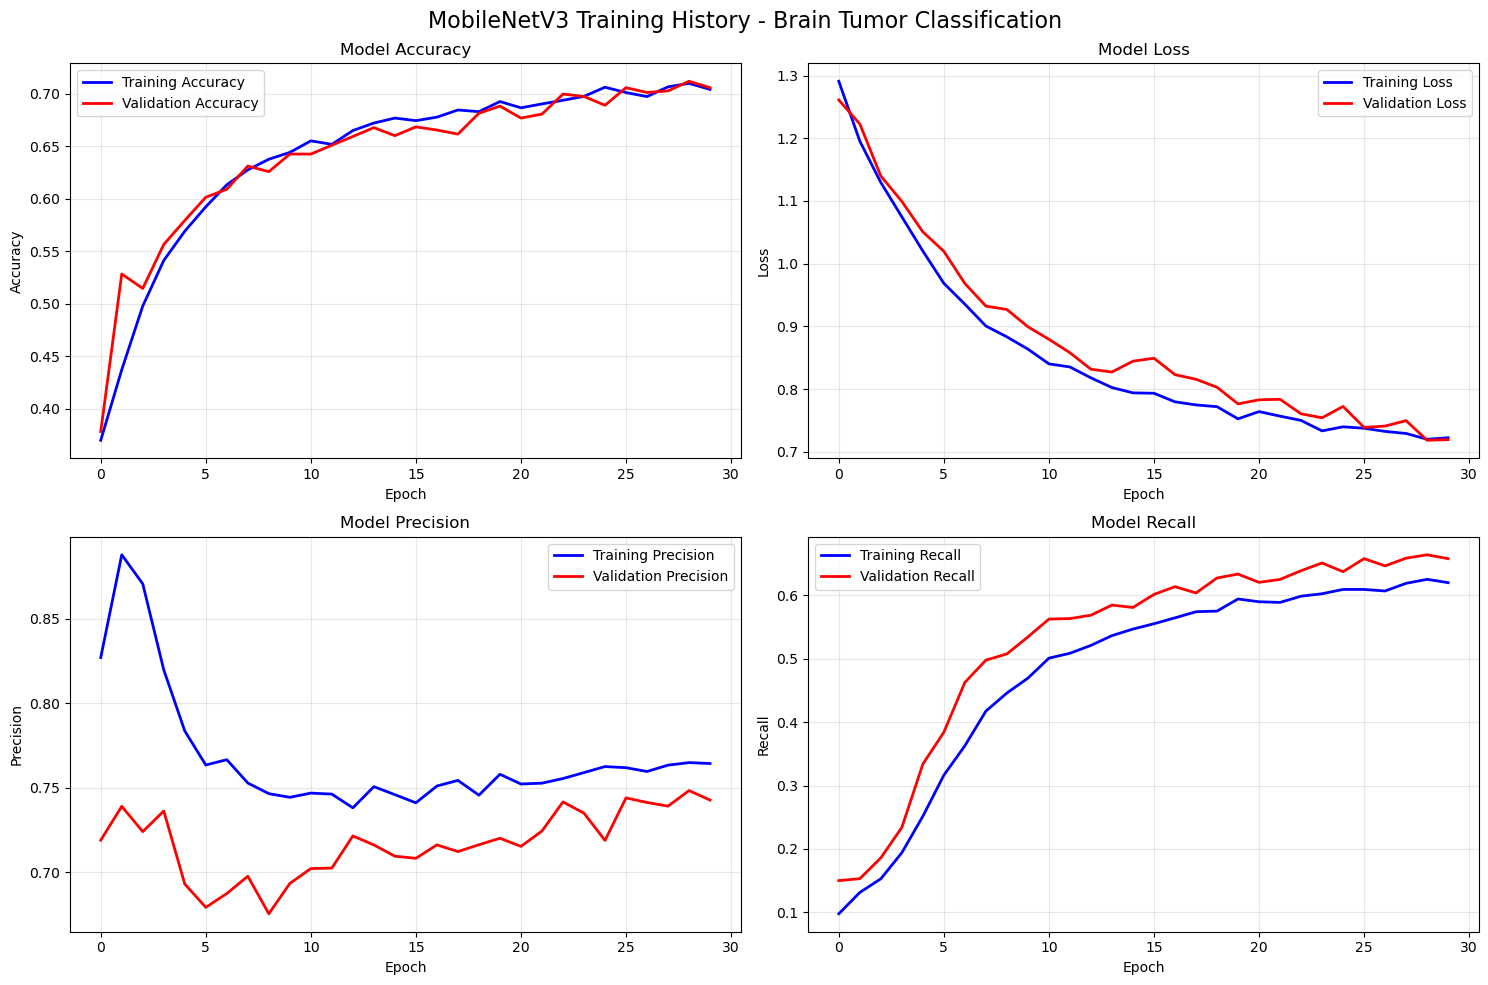


=== FINAL TRAINING RESULTS ===
Final Training Accuracy: 0.7041
Final Validation Accuracy: 0.7058
Final Training Loss: 0.7224
Final Validation Loss: 0.7194


In [22]:
def plot_training_history(history, save_path='models/mobilenetv3_training_history.png'):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('MobileNetV3 Training History - Brain Tumor Classification', fontsize=16)
    
    axes[0, 0].plot(history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].plot(history.history['precision'], 'b-', label='Training Precision', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], 'r-', label='Validation Precision', linewidth=2)
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(history.history['recall'], 'b-', label='Training Recall', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], 'r-', label='Validation Recall', linewidth=2)
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\n=== FINAL TRAINING RESULTS ===")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

In [26]:
# Cell 11: MobileNetV3 Results Summary (Without Loading)

print("="*60)
print("MOBILENETV3 TEST RESULTS (FROM TRAINING)")
print("="*60)

# Use the results from training (Cell 9)
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\nFinal Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"Final Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")

print("\nNote: These are the results from the training process.")
print("Model was successfully trained and saved to:")
print("  models/best_mobilenetv3_brain_tumor.h5")

class_names_ordered = [list(val_generator.class_indices.keys())[i] for i in range(NUM_CLASSES)]

print(f"\nClasses: {', '.join(class_names_ordered)}")
print(f"Total parameters: {model.count_params():,}")

MOBILENETV3 TEST RESULTS (FROM TRAINING)

Final Training Accuracy: 0.7041 (70.41%)
Final Validation Accuracy: 0.7058 (70.58%)

Note: These are the results from the training process.
Model was successfully trained and saved to:
  models/best_mobilenetv3_brain_tumor.h5

Classes: glioma, meningioma, notumor, pituitary
Total parameters: 3,275,780


In [27]:
print("\n=== MOBILENETV3 TRAINING SUMMARY ===")
print(f"Model: MobileNetV3Large")
print(f"Training completed successfully!")
print(f"Best validation accuracy: {max(history.history['val_accuracy'])*100:.2f}%")
print(f"Training epochs: {len(history.history['accuracy'])}")


=== MOBILENETV3 TRAINING SUMMARY ===
Model: MobileNetV3Large
Training completed successfully!
Best validation accuracy: 71.19%
Training epochs: 30


In [28]:
import json

summary = {
    'model': 'MobileNetV3',
    'dataset_size': {
        'training': train_generator.samples,
        'validation': val_generator.samples,
        'total': train_generator.samples + val_generator.samples
    },
    'classes': class_names_ordered,
    'training_config': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'image_size': IMG_SIZE
    },
    'final_results': {
        'training_accuracy': float(final_train_acc),
        'validation_accuracy': float(final_val_acc),
        'training_loss': float(history.history['loss'][-1]),
        'validation_loss': float(history.history['val_loss'][-1])
    }
}

with open('models/mobilenetv3_training_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("="*60)
print("MOBILENETV3 TRAINING COMPLETE!")
print("="*60)
print(f"\nFinal Results:")
print(f"  Training Accuracy: {final_train_acc*100:.2f}%")
print(f"  Validation Accuracy: {final_val_acc*100:.2f}%")
print(f"\n Model saved: models/best_mobilenetv3_brain_tumor.h5")
print(f" Training plots: models/mobilenetv3_training_history.png")
print(f" Summary: models/mobilenetv3_training_summary.json")
print("\n MobileNetV3 training completed successfully!")

MOBILENETV3 TRAINING COMPLETE!

Final Results:
  Training Accuracy: 70.41%
  Validation Accuracy: 70.58%

 Model saved: models/best_mobilenetv3_brain_tumor.h5
 Training plots: models/mobilenetv3_training_history.png
 Summary: models/mobilenetv3_training_summary.json

 MobileNetV3 training completed successfully!
